# Lecture 2 — Data Exploration & Preprocessing
### Introduction to Machine Learning Applications for Sustainability Research
**Profs. Lucas Zanon & Tiago Sigahi — USP / POLIMI**

**Dataset:** `sdg8_dataset_final.xlsx` — we want to predict the **SDG 8 score (`goal8`)**, a *regression* target, from indicators of the other SDGs. This is the hands-on companion to Lecture 2 and the foundation for next class's regression models.

**Roadmap (mirrors the slides):**
1. Why visualize data? (Anscombe's Quartet)
2. Core chart types for EDA (distribution, correlation, ranking, evolution)
3. Data preprocessing (missing data, outliers, encoding, scaling, train/test split & leakage)
4. Model-ready output for next class

> In Google Colab: `Runtime > Run all`. Under each chart there is a short note on what it tells us about **sustainability** or **machine learning**.

## 0. Setup, loading & first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn

sns.set_theme(style = "whitegrid", palette = "deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
np.random.seed(42)

In [2]:
# The file ships with two sheets: training period (2000-2018) and test period (2019-2024).
import os
FILE = "sdg8_dataset_final.xlsx"
if not os.path.exists(FILE):
    from google.colab import files
    print("Please upload sdg8_dataset_final.xlsx")
    uploaded = files.upload()
    FILE = list(uploaded.keys())[0]

train_raw = pd.read_excel(FILE, sheet_name = 0)   # 2000-2018
test_raw  = pd.read_excel(FILE, sheet_name = 1)   # 2019-2024
train_raw

,id,Country,year,indexreg,sdg1_wpc,sdg1_lmicpov,sdg2_undernsh,sdg2_obesity,sdg2_trophic,sdg2_crlyld,...,sdg13_ghgimport,sdg14_cpma,sdg14_discard,sdg15_cpta,sdg15_cpfa,sdg15_redlist,sdg16_homicides,sdg16_prison,sdg17_govex,goal8
0,AFG,Afghanistan,2000,E. Europe & C. Asia,43.749,66.492,NaN,4.250,2.295,0.806,...,0.854,NaN,NaN,0.000,0.000,0.927,NaN,NaN,NaN,47.746000
1,AFG,Afghanistan,2001,E. Europe & C. Asia,49.485,71.875,46.000,4.600,2.217,1.007,...,0.949,NaN,NaN,0.000,0.000,0.926,NaN,NaN,NaN,47.734429
2,AFG,Afghanistan,2002,E. Europe & C. Asia,40.084,63.283,43.700,4.970,2.294,1.670,...,0.871,NaN,NaN,0.000,0.000,0.926,NaN,NaN,NaN,47.750286
3,AFG,Afghanistan,2003,E. Europe & C. Asia,38.028,61.379,38.600,5.370,2.264,1.458,...,0.787,NaN,NaN,0.000,0.000,0.926,NaN,NaN,NaN,47.768429
4,AFG,Afghanistan,2004,E. Europe & C. Asia,38.922,62.417,35.900,5.790,2.265,1.335,...,0.808,NaN,NaN,0.000,0.000,0.926,NaN,22.341,NaN,47.759143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3738,_World,World,2014,NaN,8.638,20.779,8.251,12.363,2.253,4.194,...,1.568,26.423,7.169,29.821,28.988,0.806,5.815,NaN,6.804,70.379714
3739,_World,World,2015,NaN,8.242,19.426,8.231,12.726,2.254,4.196,...,1.506,26.575,6.884,30.058,29.222,0.803,5.645,NaN,6.915,69.946571
3740,_World,World,2016,NaN,8.089,18.387,8.164,13.110,2.256,4.231,...,1.443,27.126,6.836,30.466,29.425,0.801,5.696,NaN,6.831,69.962429
3741,_World,World,2017,NaN,7.931,17.606,8.038,13.497,2.257,4.311,...,1.456,27.430,6.846,30.799,29.799,0.799,5.643,NaN,6.815,71.342571


In [3]:
train_raw.head(10)

,id,Country,year,indexreg,sdg1_wpc,sdg1_lmicpov,sdg2_undernsh,sdg2_obesity,sdg2_trophic,sdg2_crlyld,...,sdg13_ghgimport,sdg14_cpma,sdg14_discard,sdg15_cpta,sdg15_cpfa,sdg15_redlist,sdg16_homicides,sdg16_prison,sdg17_govex,goal8
0,AFG,Afghanistan,2000,E. Europe & C. Asia,43.749,66.492,NaN,4.25,2.295,0.806,...,0.854,NaN,NaN,0.000,0.0,0.927,NaN,NaN,NaN,47.746000
1,AFG,Afghanistan,2001,E. Europe & C. Asia,49.485,71.875,46.0,4.60,2.217,1.007,...,0.949,NaN,NaN,0.000,0.0,0.926,NaN,NaN,NaN,47.734429
2,AFG,Afghanistan,2002,E. Europe & C. Asia,40.084,63.283,43.7,4.97,2.294,1.670,...,0.871,NaN,NaN,0.000,0.0,0.926,NaN,NaN,NaN,47.750286
3,AFG,Afghanistan,2003,E. Europe & C. Asia,38.028,61.379,38.6,5.37,2.264,1.458,...,0.787,NaN,NaN,0.000,0.0,0.926,NaN,NaN,NaN,47.768429
4,AFG,Afghanistan,2004,E. Europe & C. Asia,38.922,62.417,35.9,5.79,2.265,1.335,...,0.808,NaN,NaN,0.000,0.0,0.926,NaN,22.341,NaN,47.759143
5,AFG,Afghanistan,2005,E. Europe & C. Asia,35.607,59.160,34.2,6.24,2.251,1.790,...,0.628,NaN,NaN,0.000,0.0,0.926,NaN,NaN,NaN,47.762714
6,AFG,Afghanistan,2006,E. Europe & C. Asia,34.358,57.964,31.6,6.72,2.226,1.552,...,0.643,NaN,NaN,0.000,0.0,0.926,NaN,30.287,5.185,47.739286
7,AFG,Afghanistan,2007,E. Europe & C. Asia,29.723,53.005,28.3,7.23,2.227,1.915,...,0.591,NaN,NaN,0.000,0.0,0.926,NaN,40.883,4.735,47.799571
8,AFG,Afghanistan,2008,E. Europe & C. Asia,28.834,52.069,25.1,7.78,2.227,1.455,...,0.431,NaN,NaN,0.000,0.0,0.926,NaN,47.300,5.014,47.756714
9,AFG,Afghanistan,2009,E. Europe & C. Asia,21.987,44.012,21.6,8.35,2.220,2.041,...,0.433,NaN,NaN,5.822,0.0,0.926,4.06,NaN,5.341,47.845000


In [4]:
train_raw.describe()

,year,sdg1_wpc,sdg1_lmicpov,sdg2_undernsh,sdg2_obesity,sdg2_trophic,sdg2_crlyld,sdg2_snmi,sdg3_matmort,sdg3_neonat,...,sdg13_ghgimport,sdg14_cpma,sdg14_discard,sdg15_cpta,sdg15_cpfa,sdg15_redlist,sdg16_homicides,sdg16_prison,sdg17_govex,goal8
count,3743.000000,3268.000000,3268.000000,3229.000000,3743.000000,3480.000000,3551.000000,3707.000000,3743.000000,3743.000000,...,3240.000000,2831.000000,2639.000000,3743.000000,3211.000000,3743.000000,2442.000000,2113.000000,3245.000000,3743.000000
mean,2009.000000,16.233196,27.697151,11.534236,16.241149,2.277186,3.247609,0.876848,190.509744,16.380285,...,2.983645,34.899416,9.452123,38.437932,42.220530,0.865087,8.226300,173.579613,7.385476,68.542780
std,5.477957,20.514974,27.956602,11.262985,10.028186,0.122293,2.806809,0.232409,269.030893,12.715035,...,3.730660,27.777673,10.920315,25.615824,29.988277,0.092940,12.201116,143.895741,3.338320,8.440990
min,2000.000000,0.001000,0.007000,2.500000,0.310000,2.021000,0.000000,0.003000,1.210000,0.862000,...,0.001000,0.000000,0.000000,0.000000,0.000000,0.417000,0.000000,15.259000,0.863000,40.103250
25%,2004.000000,0.790750,1.490250,2.500000,7.620000,2.180000,1.491000,0.736000,15.770000,5.110500,...,0.536750,10.478000,2.155500,18.789000,18.258000,0.807000,1.453000,78.586000,4.766000,63.825286
50%,2009.000000,6.495000,18.161500,7.000000,16.270000,2.276000,2.750000,0.868000,66.790000,12.542000,...,1.398000,31.608000,6.352000,34.471000,36.702000,0.886000,3.392000,132.834000,6.975000,69.096286
75%,2014.000000,25.371000,48.629500,16.600000,22.220000,2.378250,4.173000,1.016000,269.516500,25.697500,...,4.331000,53.696000,12.877500,56.820000,61.379000,0.936000,8.840750,221.340000,9.514000,73.969686
max,2018.000000,89.810000,99.576000,71.400000,68.180000,2.677000,36.762000,1.410000,1662.000000,62.221000,...,27.459000,100.000000,84.558000,100.000000,100.000000,0.993000,107.638000,1246.809000,24.405000,90.719000


In [5]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3743 entries, 0 to 3742
Data columns (total 60 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3743 non-null   object 
 1   Country          3743 non-null   object 
 2   year             3743 non-null   int64  
 3   indexreg         3458 non-null   object 
 4   sdg1_wpc         3268 non-null   float64
 5   sdg1_lmicpov     3268 non-null   float64
 6   sdg2_undernsh    3229 non-null   float64
 7   sdg2_obesity     3743 non-null   float64
 8   sdg2_trophic     3480 non-null   float64
 9   sdg2_crlyld      3551 non-null   float64
 10  sdg2_snmi        3707 non-null   float64
 11  sdg3_matmort     3743 non-null   float64
 12  sdg3_neonat      3743 non-null   float64
 13  sdg3_u5mort      3743 non-null   float64
 14  sdg3_tb          3720 non-null   float64
 15  sdg3_hiv         2949 non-null   float64
 16  sdg3_ncds        3705 non-null   float64
 17  sdg3_traffic  

**What we are looking at.** 197 countries described by 55 SDG indicators, one row per country-year. In `.describe()` the `count` line already tells a story: several columns have far fewer non-null values than others — **missing data** we will quantify and fix in Part 3. The target `goal8` ranges from ~40 to ~91.

In [6]:
# Column roles — decide this before any modeling.
TARGET   = "goal8"                 # regression target
ID_COLS  = ["id", "Country"]       # identifiers, never predictors
CAT_COLS = ["indexreg"]            # categorical: world region
NUM_COLS = [c for c in train_raw.columns
            if c not in ID_COLS + CAT_COLS + [TARGET, "year"]
            and pd.api.types.is_numeric_dtype(train_raw[c])]
print("numeric predictors:", len(NUM_COLS))

numeric predictors: 55


## Part 1 — Why visualize data?
> *"Summary statistics alone can hide curvature, outliers, and clusters. Always plot your data before modeling it."*

Set I   mean(y) = 7.50   corr = 0.82
Set II  mean(y) = 7.50   corr = 0.82
Set III mean(y) = 7.50   corr = 0.82
Set IV  mean(y) = 7.50   corr = 0.82


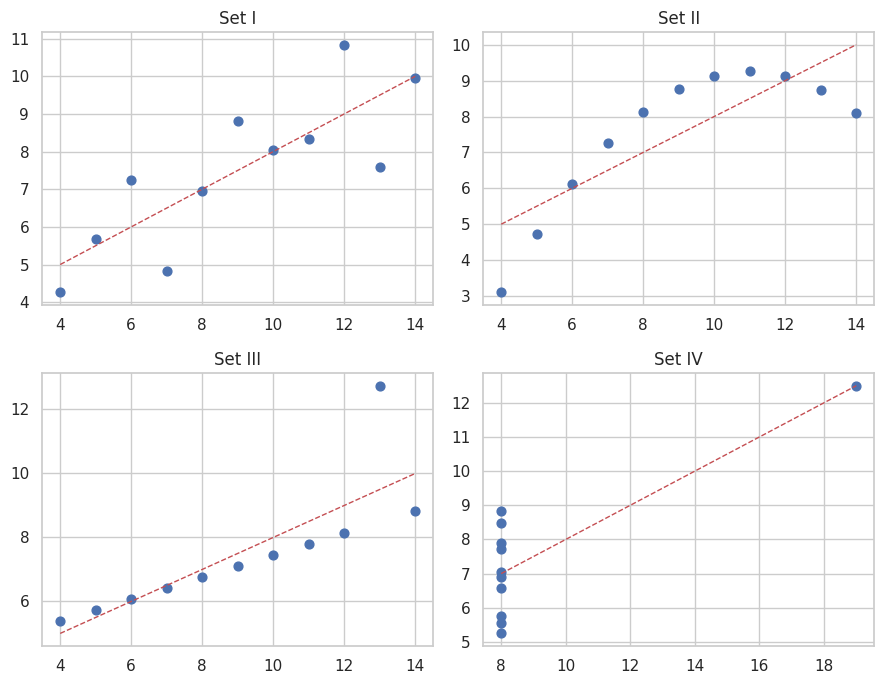

In [7]:
# Anscombe's Quartet — four datasets, hard-coded so it runs offline.
x1 = [10,8,13,9,11,14,6,4,12,7,5]
ys = {
 "I":  [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68],
 "II": [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74],
 "III":[7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]}
x4 = [8,8,8,8,8,8,8,19,8,8,8]
y4 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]
sets = {"I":(x1,ys["I"]),"II":(x1,ys["II"]),"III":(x1,ys["III"]),"IV":(x4,y4)}

for name,(xx,yy) in sets.items():
    xx,yy = np.array(xx), np.array(yy)
    print(f"Set {name:<3} mean(y) = {yy.mean():.2f}   corr = {np.corrcoef(xx,yy)[0,1]:.2f}")

fig, ax = plt.subplots(2, 2, figsize = (9, 7))
for a,(name,(xx,yy)) in zip(ax.flat, sets.items()):
    xx,yy = np.array(xx), np.array(yy)
    a.scatter(xx, yy, s = 40)
    m,b = np.polyfit(xx, yy, 1)
    a.plot(np.sort(xx), m*np.sort(xx)+b, "r--", lw = 1)
    a.set_title(f"Set {name}")
plt.tight_layout(); plt.show()

**ML lesson.** All four sets share the same mean and correlation (0.82), yet only one is a clean line — the others hide a curve, an outlier, or a vertical cluster. Never trust `.describe()` alone; plot first. This is exactly why the rest of this lecture exists.

## Part 2 — Core chart types for EDA
Distribution → correlation → ranking → evolution, on our real SDG data.

### 2.1 Distribution — Histogram

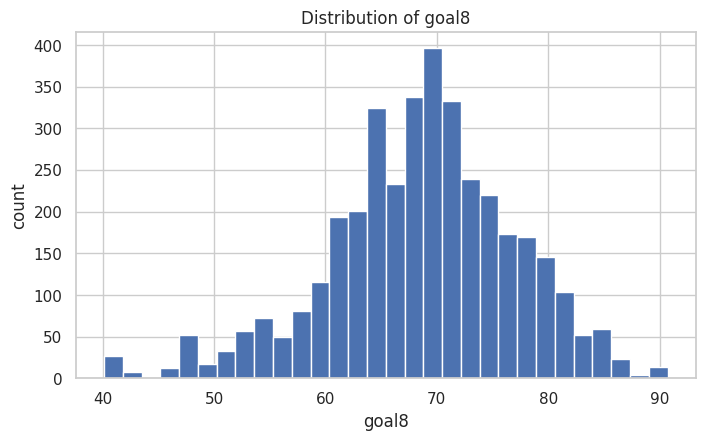

In [8]:
plt.hist(x = train_raw[TARGET], bins = 30, edgecolor = "white")
plt.xlabel(TARGET); plt.ylabel("count"); plt.title(f"Distribution of {TARGET}")
plt.show()

**Sustainability.** Decent-work scores pile up around 68–70 with a long tail toward low values: most countries do moderately well, a minority of fragile economies pulls the mean down. **ML.** A roughly bell-shaped target is friendly to linear regression next class.

### 2.2 Distribution — Boxplot & Violin

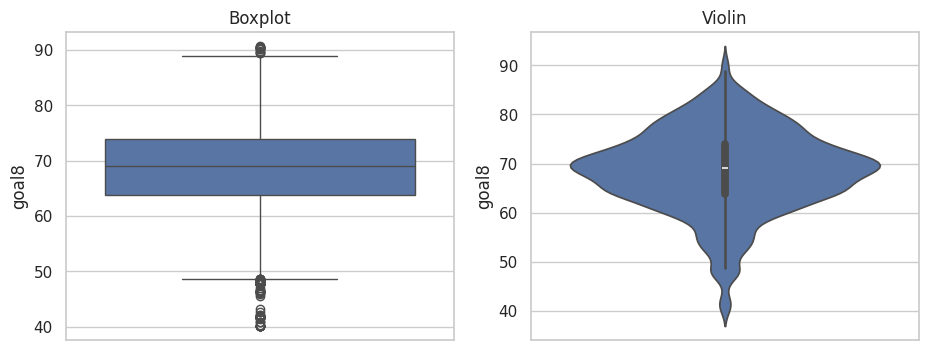

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (11, 4))
sns.boxplot(y = train_raw[TARGET], ax = ax[0]); ax[0].set_title("Boxplot")
sns.violinplot(y = train_raw[TARGET], ax = ax[1]); ax[1].set_title("Violin")
plt.show()

**What it shows.** The violin reveals a small second bulge at low scores that the boxplot smooths over — again the Anscombe lesson, summaries hide shape. Points past the whiskers are *flagged* as candidate outliers, not errors to delete on sight (we treat them in Part 3).

### 2.3 Sample composition — Count plot

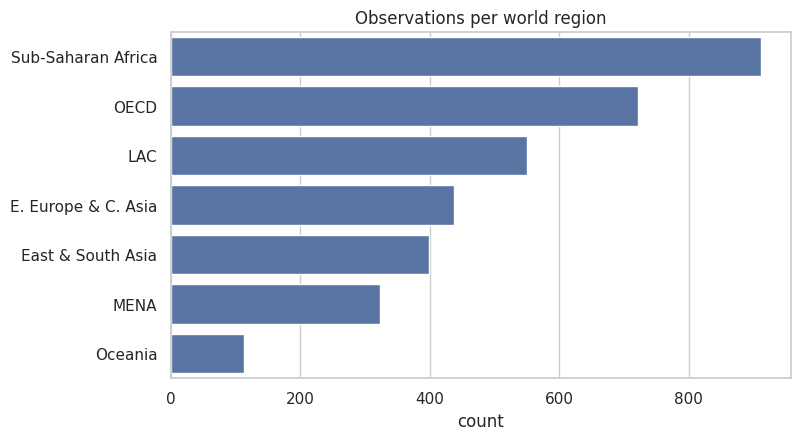

In [10]:
sns.countplot(y = train_raw["indexreg"],
              order = train_raw["indexreg"].value_counts().index)
plt.xlabel("count"); plt.ylabel(""); plt.title("Observations per world region")
plt.show()

**ML caution.** The sample is **not balanced** across regions — Sub-Saharan Africa and OECD dominate, Oceania is tiny. Imbalanced groups can bias a model toward the majority and give misleadingly good average metrics; keep this in mind before generalizing conclusions.

### 2.4 Correlation — Scatter: life expectancy vs. SDG 8

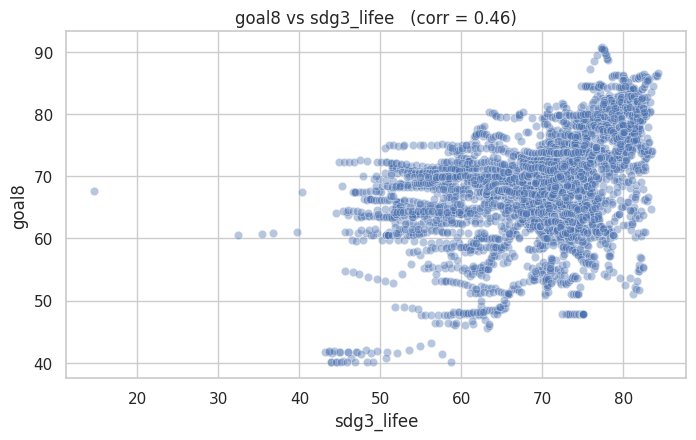

In [11]:
sns.scatterplot(data = train_raw, x = "sdg3_lifee", y = TARGET, alpha = 0.4)
r = train_raw[["sdg3_lifee", TARGET]].corr().iloc[0, 1]
plt.title(f"{TARGET} vs sdg3_lifee   (corr = {r:.2f})")
plt.show()

**Sustainability.** Life expectancy is the **single strongest correlate** of SDG 8 (r ≈ 0.46): healthier populations (SDG 3) underpin decent work and growth — a concrete example of the *wedding-cake* idea that the social base supports the economy.

### 2.5 Correlation — Scatter: internet use vs. SDG 8

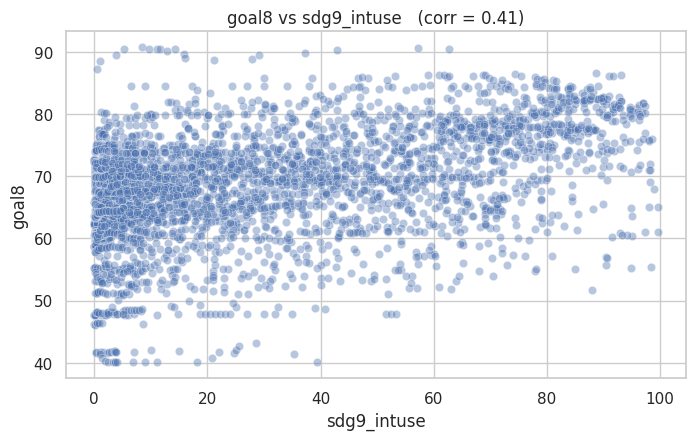

In [12]:
sns.scatterplot(data = train_raw, x = "sdg9_intuse", y = TARGET, alpha = 0.4)
r = train_raw[["sdg9_intuse", TARGET]].corr().iloc[0, 1]
plt.title(f"{TARGET} vs sdg9_intuse   (corr = {r:.2f})")
plt.show()

**Sustainability.** Internet use (SDG 9 infrastructure) also tracks decent-work scores (r ≈ 0.41). Digital access is increasingly a prerequisite for productive, modern employment — infrastructure and jobs rise together.

### 2.6 Correlation — Heatmap

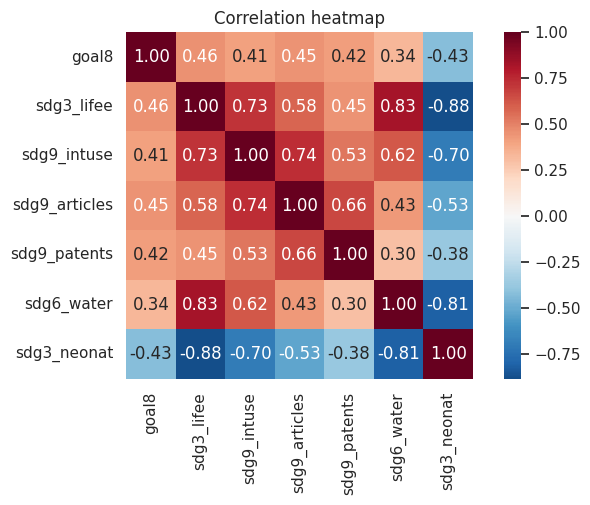

In [13]:
subset = [TARGET, "sdg3_lifee", "sdg9_intuse", "sdg9_articles",
          "sdg9_patents", "sdg6_water", "sdg3_neonat"]
sns.heatmap(train_raw[subset].corr(), annot = True, fmt = ".2f",
            cmap = "RdBu_r", center = 0, square = True)
plt.title("Correlation heatmap")
plt.show()

**ML lesson — multicollinearity.** The SDG 9 innovation indicators (internet, articles, patents) are strongly correlated *with each other*, not just with the target. Redundant features make linear-model coefficients unstable and hard to interpret — a reason to scale, regularize, or prune inputs. Note `sdg3_neonat` (neonatal mortality) correlates **negatively**: health deficits track lower economic-development scores.

### 2.7 Correlation — Scatter matrix (interactive, Plotly)

In [14]:
grafico = px.scatter_matrix(train_raw,
    dimensions = ["goal8", "sdg3_lifee", "sdg9_intuse", "sdg6_water"],
    color = "indexreg", height = 700)
grafico.update_traces(diagonal_visible = False, marker = dict(size = 3, opacity = 0.5))
grafico.show()

**What it shows.** Colored by region, the clouds separate cleanly: OECD sits high on every axis, Sub-Saharan Africa low. A model could almost predict SDG 8 from region alone — useful signal, but also a warning that we may be **encoding structural inequality** into the model.

### 2.8 Ranking — Bar chart: mean SDG 8 by region

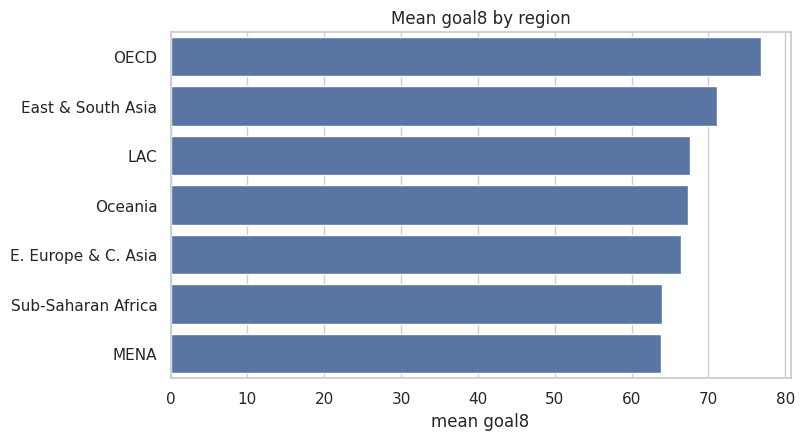

In [15]:
rank = train_raw.groupby("indexreg")[TARGET].mean().sort_values(ascending = False)
sns.barplot(x = rank.values, y = rank.index, orient = "h")
plt.xlabel(f"mean {TARGET}"); plt.ylabel(""); plt.title(f"Mean {TARGET} by region")
plt.show()

**Sustainability.** Mean SDG 8 runs from ~77 (OECD) down to ~64 (MENA). That ~13-point gap is a compact quantification of **global inequality** in decent work and economic growth.

### 2.9 Ranking + spread — Boxplot of SDG 8 by region

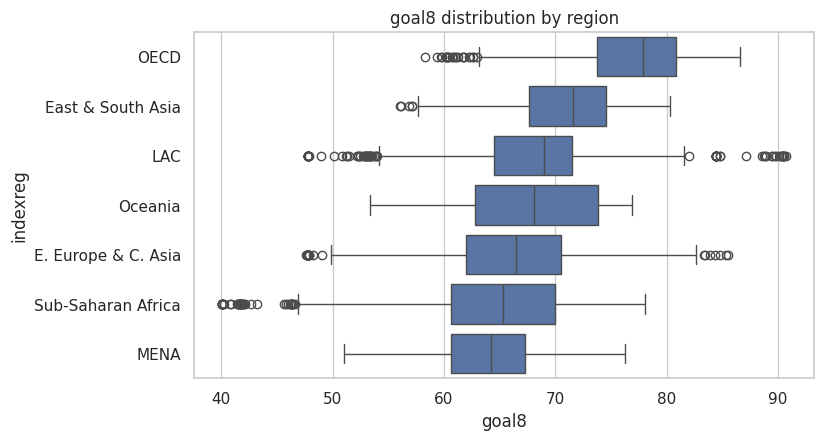

In [16]:
order = train_raw.groupby("indexreg")[TARGET].median().sort_values(ascending = False).index
sns.boxplot(data = train_raw, x = TARGET, y = "indexreg", order = order)
plt.title(f"{TARGET} distribution by region")
plt.show()

**Beyond the average.** LAC and Sub-Saharan Africa show the **widest spread** — big within-region inequality. Two countries in the same region can be worlds apart, so a single regional average would be a leaky, oversimplified feature.

### 2.10 Evolution — Line chart over time

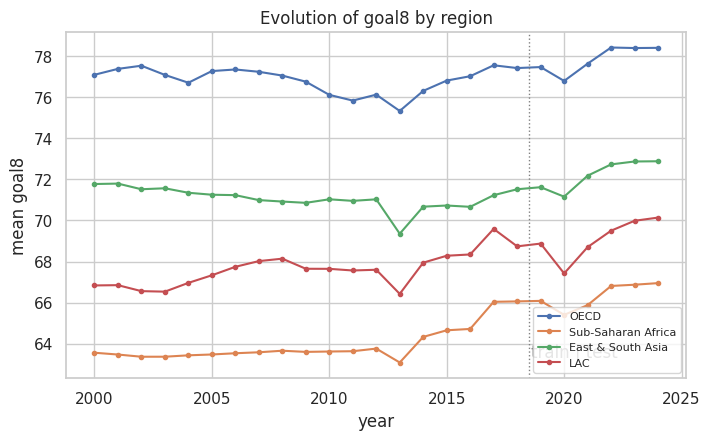

In [17]:
full = pd.concat([train_raw, test_raw], ignore_index = True)
evo = full.groupby(["year", "indexreg"])[TARGET].mean().reset_index()
for reg in ["OECD", "Sub-Saharan Africa", "East & South Asia", "LAC"]:
    d = evo[evo["indexreg"] == reg]
    plt.plot(d["year"], d[TARGET], marker = "o", ms = 3, label = reg)
plt.axvline(2018.5, color = "gray", ls = ":", lw = 1)
plt.text(2018.6, plt.ylim()[0] + 1, "train | test", color = "gray")
plt.xlabel("year"); plt.ylabel(f"mean {TARGET}"); plt.legend(fontsize = 8)
plt.title(f"Evolution of {TARGET} by region")
plt.show()

**Sustainability.** Progress is **slow and fragile**: the global mean barely moved (2000→2024, ~68→71) and dips around 2020 (COVID-19). The dotted line marks where our train period ends and the test period begins — a preview of the temporal split in Part 3.

### 2.11 Part-of-a-whole — Treemap (interactive, Plotly)

In [18]:
reg_df = train_raw.dropna(subset = ["indexreg"])
grafico = px.treemap(reg_df, path = ["indexreg"], color = TARGET,
    color_continuous_scale = "RdYlGn",
    title = "Regions sized by sample count, colored by mean SDG 8")
grafico.show()

**Reading it.** Box size = how many country-years we have for that region; color = its mean SDG 8 (green = higher). A single glance shows both **where our data comes from** and **who performs well** — the kind of summary that would take a full table otherwise.

### 2.12 Flows — Parallel categories (interactive, Plotly)

In [19]:
tmp = train_raw.dropna(subset = ["indexreg"]).copy()
tmp["sdg8_level"] = pd.qcut(tmp[TARGET], 3, labels = ["Low", "Medium", "High"])
grafico = px.parallel_categories(tmp, dimensions = ["indexreg", "sdg8_level"],
    title = "Region -> SDG 8 tier")
grafico.show()

**Structural patterns.** Most *High* flows originate in OECD and East & South Asia; most *Low* flows in Sub-Saharan Africa and MENA. Making these patterns explicit is important: a "fair" ML model should be scrutinized so it *informs* policy rather than simply **hard-coding the status quo**.

## Part 3 — Data preprocessing
> *"Garbage in, garbage out."* We build the **Clean → Encode → Scale → Split** pipeline that turns this messy table into model-ready data.

### 3.1 Missing data — quantify first

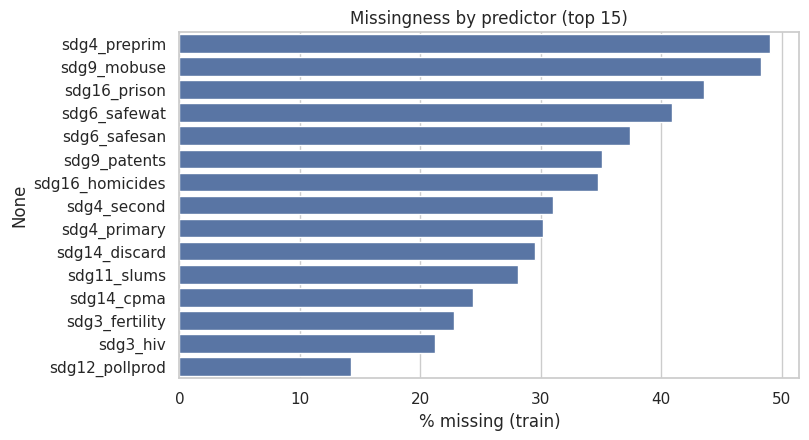

columns with >30% missing: 9


In [20]:
miss = train_raw[NUM_COLS].isna().mean().sort_values(ascending = False)
top = miss[miss > 0].head(15)
sns.barplot(x = top.values * 100, y = top.index, orient = "h")
plt.xlabel("% missing (train)"); plt.title("Missingness by predictor (top 15)")
plt.show()
print("columns with >30% missing:", (miss > 0.30).sum())

**Why it matters here.** Some indicators (pre-primary education, mobile use) are missing for ~half the rows, and the gaps are likely **not random** — poorer countries report less. Dropping those rows would delete exactly the countries we most care about, so we **impute** instead of deleting.

### 3.2 Missing data — median imputation

'sdg4_preprim': 1835 missing -> filled with median = 82.90


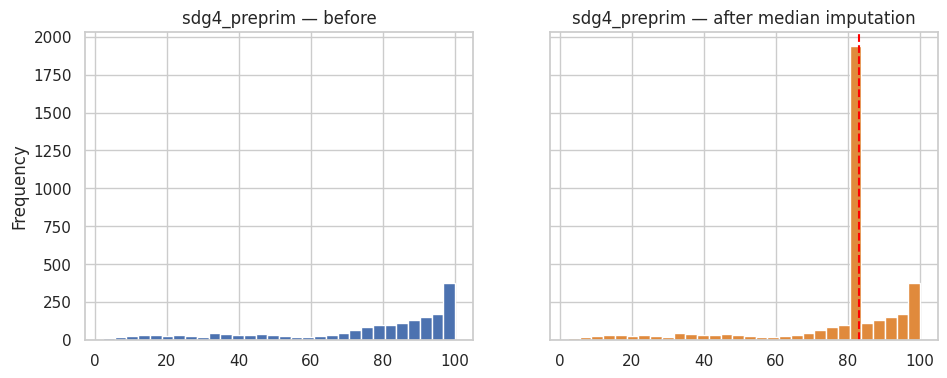

In [21]:
col = miss.index[0]
med = train_raw[col].median()
print(f"'{col}': {train_raw[col].isna().sum()} missing -> filled with median = {med:.2f}")

fig, ax = plt.subplots(1, 2, figsize = (11, 4), sharey = True)
train_raw[col].dropna().plot(kind = "hist", bins = 30, ax = ax[0], edgecolor = "white")
ax[0].set_title(f"{col} — before")
train_raw[col].fillna(med).plot(kind = "hist", bins = 30, ax = ax[1],
    edgecolor = "white", color = "#e08a3c")
ax[1].axvline(med, color = "red", ls = "--"); ax[1].set_title(f"{col} — after median imputation")
plt.show()

**Trade-off.** Median imputation fills gaps without inventing extreme values, but look at the tall bar at the median: imputation **understates true variability**. It keeps all rows at the cost of some artificial concentration — a compromise worth stating out loud.

### 3.3 Outliers — detect (IQR) then cap (winsorize)

IQR fence [48.6, 89.2] -> 117 flagged


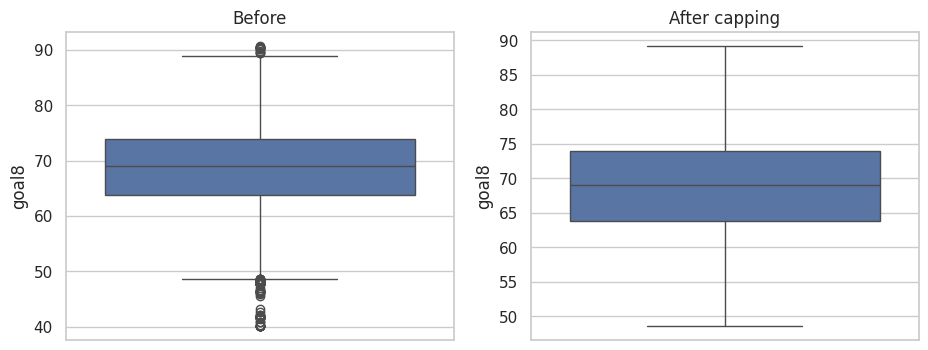

In [22]:
col = TARGET
q1, q3 = train_raw[col].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
mask = (train_raw[col] < low) | (train_raw[col] > high)
print(f"IQR fence [{low:.1f}, {high:.1f}] -> {mask.sum()} flagged")

capped = train_raw[col].clip(low, high)
fig, ax = plt.subplots(1, 2, figsize = (11, 4))
sns.boxplot(y = train_raw[col], ax = ax[0]); ax[0].set_title("Before")
sns.boxplot(y = capped, ax = ax[1]); ax[1].set_title("After capping")
plt.show()

**Investigate before treating.** The ~117 low-score country-years are **real fragile states, not recording errors** — so we *cap* (winsorize) rather than delete, keeping the observation while limiting its leverage on the model. Deleting them would erase a genuine sustainability signal.

### 3.4 Categorical encoding — Label vs One-Hot

In [23]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# WRONG for nominal data — shown to illustrate the trap
label_encoder = LabelEncoder()
demo = label_encoder.fit_transform(train_raw["indexreg"].astype(str))
print("Label encoding (do NOT use for nominal regions):")
for cls, c in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {cls:<28} -> {c}")

# CORRECT — one-hot
onehot = pd.get_dummies(train_raw["indexreg"], prefix = "reg")
onehot.head()

Label encoding (do NOT use for nominal regions):
  E. Europe & C. Asia          -> 0
  East & South Asia            -> 1
  LAC                          -> 2
  MENA                         -> 3
  OECD                         -> 4
  Oceania                      -> 5
  Sub-Saharan Africa           -> 6
  nan                          -> 7


,reg_E. Europe & C. Asia,reg_East & South Asia,reg_LAC,reg_MENA,reg_OECD,reg_Oceania,reg_Sub-Saharan Africa
0,True,False,False,False,False,False,False
1,True,False,False,False,False,False,False
2,True,False,False,False,False,False,False
3,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False


**ML lesson.** Label-encoding would tell the model "OECD (4) > MENA (3)", a **false ranking** with no real meaning. One-hot encoding creates one binary column per region and avoids inventing order — the right choice for nominal sustainability categories.

### 3.5 Feature scaling — Standardization vs Min-Max

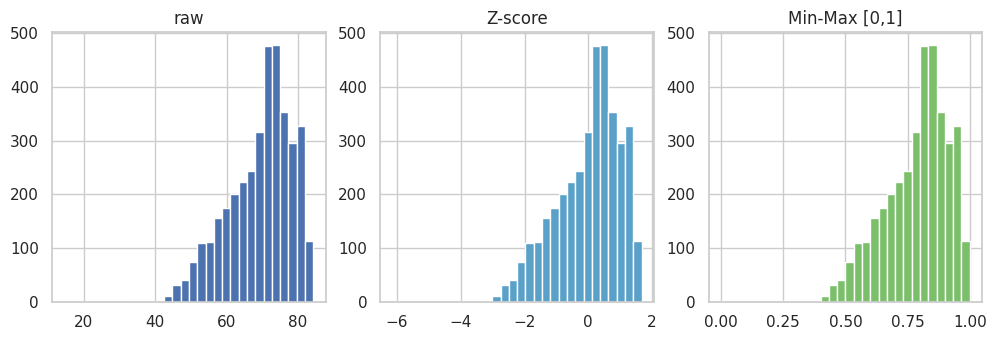

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
col = "sdg3_lifee"
s = train_raw[[col]].dropna()
z  = StandardScaler().fit_transform(s)
mm = MinMaxScaler().fit_transform(s)

fig, ax = plt.subplots(1, 3, figsize = (12, 3.5))
ax[0].hist(s, bins = 30, edgecolor = "white"); ax[0].set_title("raw")
ax[1].hist(z, bins = 30, edgecolor = "white", color = "#5aa1c9"); ax[1].set_title("Z-score")
ax[2].hist(mm, bins = 30, edgecolor = "white", color = "#7bbf6a"); ax[2].set_title("Min-Max [0,1]")
plt.show()

**Why scale.** The *shape* is unchanged — only the axis moves. But our indicators live on wildly different ranges, and distance-based models (KNN, next class) would otherwise be dominated by large-range variables regardless of how predictive they are.

### 3.6 Train/test split & data leakage
> *"Split before you scale or impute. Fitting preprocessing on the full dataset lets test information leak into training."*

**Two strategies to know:** (1) a **random** `train_test_split` (the classic technique), and (2) a **temporal** split — the sheets are already divided by year. For time-ordered / panel data the temporal split is the honest one: using future years to predict the past is itself a subtle leakage.

In [25]:
from sklearn.model_selection import train_test_split

# Strategy 1 — random (the technique from the slides)
full = pd.concat([train_raw, test_raw], ignore_index = True)
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    full[NUM_COLS], full[TARGET], test_size = 0.2, random_state = 42)
print("random   -> train:", Xtr_r.shape[0], "test:", Xte_r.shape[0])

# Strategy 2 — temporal (correct here): we use the pre-split sheets
print("temporal -> train:", train_raw.shape[0], "(<=2018)  test:", test_raw.shape[0], "(>=2019)")

random   -> train: 3940 test: 985
temporal -> train: 3743 (<=2018)  test: 1182 (>=2019)


**Which to trust?** For a real SDG *forecast* we want the temporal split — it answers the honest question "given the past, can we predict future years?". The random split mixes years and looks better on paper precisely because it leaks time. We proceed with the temporal split below.

In [26]:
# Build model-ready matrices from the temporal split.
# Fit every transformer on TRAIN ONLY, then apply to TEST (no leakage).
from sklearn.impute import SimpleImputer

y_train = train_raw[TARGET].values
y_test  = test_raw[TARGET].values

num_imputer = SimpleImputer(strategy = "median").fit(train_raw[NUM_COLS])
scaler = StandardScaler().fit(num_imputer.transform(train_raw[NUM_COLS]))
Xtr_num = scaler.transform(num_imputer.transform(train_raw[NUM_COLS]))
Xte_num = scaler.transform(num_imputer.transform(test_raw[NUM_COLS]))

try:
    ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown = "ignore", sparse = False)
ohe.fit(train_raw[CAT_COLS].astype(str))
Xtr_cat = ohe.transform(train_raw[CAT_COLS].astype(str))
Xte_cat = ohe.transform(test_raw[CAT_COLS].astype(str))

feat_names = NUM_COLS + list(ohe.get_feature_names_out(CAT_COLS))
X_train = pd.DataFrame(np.hstack([Xtr_num, Xtr_cat]), columns = feat_names)
X_test  = pd.DataFrame(np.hstack([Xte_num, Xte_cat]), columns = feat_names)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("no NaNs left ->", not X_train.isna().any().any() and not X_test.isna().any().any())
X_train.head()

X_train: (3743, 63)  X_test: (1182, 63)
no NaNs left -> True


,sdg1_wpc,sdg1_lmicpov,sdg2_undernsh,sdg2_obesity,sdg2_trophic,sdg2_crlyld,sdg2_snmi,sdg3_matmort,sdg3_neonat,sdg3_u5mort,...,sdg16_prison,sdg17_govex,indexreg_E. Europe & C. Asia,indexreg_East & South Asia,indexreg_LAC,indexreg_MENA,indexreg_OECD,indexreg_Oceania,indexreg_Sub-Saharan Africa,indexreg_nan
0,1.479117,1.520482,-0.369880,-1.195904,0.151797,-0.883172,1.380429,4.392239,3.605719,2.084803,...,-0.209180,-0.11439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.774204,1.725075,3.317968,-1.160998,-0.509769,-0.809698,1.341511,4.165469,3.507318,1.987456,...,-0.209180,-0.11439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.290573,1.398516,3.100479,-1.124097,0.143315,-0.567346,0.822613,3.987027,3.407659,1.888657,...,-0.209180,-0.11439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.184802,1.326150,2.618222,-1.084204,-0.111133,-0.644841,0.623702,3.756540,3.299977,1.787049,...,-0.209180,-0.11439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.230794,1.365602,2.362910,-1.042317,-0.102652,-0.689802,0.973958,3.626426,3.192059,1.683528,...,-1.214012,-0.11439,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**The golden rule in code.** The imputer's medians and the scaler's means come **only from `train_raw`** and are then *applied* to `test_raw`. The test set never influences the transformations — this is what keeps evaluation honest next class.

### 3.7 (Bonus) The professional shortcut — `Pipeline` + `ColumnTransformer`

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy = "median")),
                         ("scale",  StandardScaler())])
try:
    cat_ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
except TypeError:
    cat_ohe = OneHotEncoder(handle_unknown = "ignore", sparse = False)

preprocess = ColumnTransformer([("num", numeric_pipe, NUM_COLS),
                                ("cat", cat_ohe, CAT_COLS)])
Xtr_p = preprocess.fit_transform(train_raw)   # fit on train only
Xte_p = preprocess.transform(test_raw)
print("pipeline X_train:", Xtr_p.shape, " matches manual:", np.allclose(Xtr_p, X_train.values))

pipeline X_train: (3743, 63)  matches manual: True


**Same result, safer.** The `ColumnTransformer` does the exact same steps as 3.6 in one object (`np.allclose` confirms it). Bundling preprocessing into a `Pipeline` makes leakage almost impossible and plugs straight into the models we build next class.

## Part 4 — Wrap-up & handoff
We turned a raw 60-column table into clean, encoded, scaled matrices `X_train / X_test / y_train / y_test`, split honestly by time.

**Key takeaways:** always plot before modeling (Anscombe); match the chart to the data; preprocessing makes data model-ready; split **before** you scale or impute.

**Discussion prompts:** Which predictors correlated most with `goal8`, and do they fit the *wedding-cake* logic? Random vs. temporal split — which would you trust for a real forecast? Which regression model next class will care most about scaling? Next class we feed `X_train, y_train` straight into regression models to predict SDG 8.